# Red neuronal artificial para reconocer el tipo de un pokemon

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

A continuación se instancia el dataset y se itera para presentar algunos ejemplos:

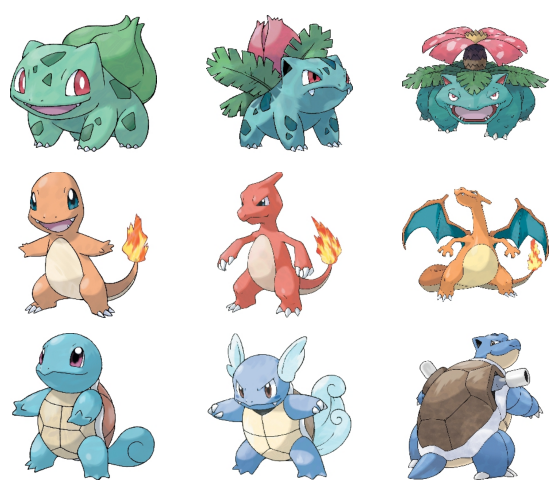

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');

Cada ejemplo tiene su imagen, su etiqueta, su nombre y sus atributos:

In [2]:
image, label, name, attributes = dataset[0]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(9),
 'Bulbasaur',
 tensor([ 0.7000,  6.9000, 45.0000, 49.0000, 49.0000, 45.0000]))

Se puede obtener el nombre de la clase con:

In [3]:
dataset.categories[label]

'Grass'

Y los atributos disponibles son:

In [4]:
dataset.attribute_names

['Height', 'Weight', 'HP', 'Attack', 'Defense', 'Speed']

La cantidad de ejemplos por clase es:

In [5]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


En lo que sigue utilice los siguientes conjuntos de entrenamiento (train) y prueba (test). 

In [6]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)),test_size=0.15, random_state=1234, 
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

# Definición del modelo

Se decidió utilizar una Red Neuronal Convolucional (CNN) inspirada en la arquitectura LeNet-5. Esta decisión se tomó debido a que el problema consiste en clasificar imágenes de Pokémon, y las redes convolucionales fueron diseñadas específicamente para procesar datos organizados como una grilla regular, como imágenes, series de tiempo y video. En particular, las CNN permiten aprender automáticamente filtros capaces de detectar bordes, formas, colores y patrones visuales relevantes presentes en las imágenes.

Se optó por una arquitectura inspirada en LeNet-5 debido a su simplicidad y efectividad para tareas de clasificación de imágenes. Aunque originalmente fue desarrollada para el reconocimiento de dígitos manuscritos, sus principios pueden aplicarse a cualquier problema de clasificación visual. Además, el conjunto de datos utilizado contiene **595 imágenes** (suma de los conteos por clase obtenidos en la sección de exploración de datos), por lo que una arquitectura excesivamente profunda podría aumentar el riesgo de sobreajuste. Por esta razón, se seleccionó una arquitectura relativamente simple, capaz de aprender características visuales relevantes sin requerir una gran cantidad de datos para su entrenamiento.

Durante el análisis inicial del conjunto de datos se identificaron 17 categorías de tipo Pokémon (Bug, Dark, Dragon, Electric, Fairy, Fighting, Fire, Ghost, Grass, Ground, Ice, Normal, Poison, Psychic, Rock, Steel, Water). Sin embargo, al verificar explícitamente los valores de etiqueta presentes en el dataset se encontró un valor adicional (etiqueta `17`) no contemplado en ese conteo inicial por categoría. Por este motivo la capa de salida se definió finalmente con **18 neuronas** en lugar de 17. Esta diferencia debería verificarse directamente en la implementación de `PokemonImages` (en `pokemon_utils.py`) para confirmar a qué corresponde exactamente esa clase adicional (por ejemplo, podría tratarse de un tipo secundario no señalado en el resumen por categoría, o de una clase reservada para casos sin un tipo asignado).

## Arquitectura propuesta

```text
Imagen RGB 256×256                     Atributos numéricos (6)
        ↓                                       │
 Conv1 → ReLU → MaxPooling                       │
        ↓                                       │
 Conv2 → ReLU → MaxPooling                       │
        ↓                                       │
 Conv3 → ReLU → MaxPooling                       │
        ↓                                       │
 Global Average Pooling                         │
        ↓                                       │
     Flatten                                    │
        └───────────────── Concatenación ───────┘
                            ↓
                 Fully Connected (fc1) → ReLU
                            ↓
                         Dropout
                            ↓
                 Capa de Salida (fc2)
```

## Descripción de cada componente

- **Conv1:** Corresponde a la primera capa convolucional. Su objetivo es detectar características visuales básicas presentes en la imagen, tales como bordes, contrastes, cambios de color y texturas simples.

- **ReLU:** Corresponde a la función de activación ReLU (Rectified Linear Unit). Su función es introducir no linealidad en el modelo, permitiendo aprender relaciones más complejas entre las características visuales y las clases objetivo.

- **MaxPooling:** Esta capa reduce el tamaño de las representaciones internas generadas por la convolución, conservando la información más relevante. Esto disminuye el costo computacional y ayuda a reducir el riesgo de sobreajuste.

- **Conv2:** Corresponde a la segunda capa convolucional. Esta capa combina las características aprendidas por la primera capa para identificar patrones de mayor complejidad, como formas, contornos y partes características de los Pokémon.

- **Conv3:** Corresponde a la tercera capa convolucional. Su objetivo es construir representaciones más abstractas de la imagen, identificando estructuras visuales complejas a partir de la combinación de las características aprendidas en las capas anteriores.

- **Global Average Pooling:** Tras el tercer bloque convolucional, cada uno de los 64 mapas de características se reduce a un único valor promedio (de 64×32×32 a 64×1×1). Esto disminuye drásticamente el número de parámetros de las capas siguientes y ayuda a evitar el sobreajuste, a costa de perder información espacial fina.

- **Flatten:** Transforma la salida del Global Average Pooling (64×1×1) en un vector unidimensional de 64 valores, permitiendo conectar la etapa de extracción de características visuales con las capas de clasificación.

- **Concatenación de atributos:** El vector de 64 características visuales se concatena con los 6 atributos numéricos del Pokémon (altura, peso, HP, ataque, defensa y velocidad), formando un vector combinado de 70 valores. De esta forma el modelo no clasifica solo a partir de la imagen, sino que también incorpora información tabular del Pokémon.

- **Fully Connected:** Capa densa que recibe el vector combinado de 70 valores (64 visuales + 6 atributos) y lo proyecta a 128 dimensiones, combinando ambas fuentes de información para generar la predicción final.

- **Dropout:** Corresponde a una técnica de regularización utilizada para reducir el riesgo de sobreajuste. Durante el entrenamiento desactiva aleatoriamente un 30% de las neuronas, obligando a la red a aprender representaciones más robustas y mejorando su capacidad de generalización.

- **Capa de Salida:** Entrega la clasificación final del tipo de Pokémon. Se utilizan 18 neuronas de salida, una por cada valor de etiqueta presente en el dataset (ver la nota más arriba sobre la diferencia respecto a las 17 categorías de tipo identificadas inicialmente), permitiendo que la red asigne una probabilidad a cada clase y seleccione la más probable como predicción final.


In [7]:
#dimencionalidad de la imagen
# numero de clases
print(image.shape)
print(attributes.shape)

labels = [dataset[i][1] for i in range(len(dataset))]
print("Número de clases:", len(set(labels)))

torch.Size([3, 256, 256])
torch.Size([6])
Número de clases: 17


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PokemonCNN(nn.Module):

    def __init__(self):

        # Inicializa la clase padre de PyTorch
        super().__init__()

        # =====================================================
        # CAPAS CONVOLUCIONALES
        # =====================================================

        # Primera capa convolucional
        # Recibe imágenes RGB (3 canales)
        # Genera 16 mapas de características
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        # Segunda capa convolucional
        # Recibe los 16 mapas generados anteriormente
        # y produce 32 mapas de características
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Tercera capa convolucional
        # Permite aprender patrones visuales más complejos
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # =====================================================
        # MAX POOLING
        # =====================================================

        # Reduce a la mitad las dimensiones espaciales
        # Ejemplo:
        # 256x256 -> 128x128
        # 128x128 -> 64x64
        # 64x64 -> 32x32
        self.pool = nn.MaxPool2d(kernel_size=2)

        # =====================================================
        # GLOBAL AVERAGE POOLING
        # =====================================================

        # Convierte cada mapa de características
        # en un único valor promedio.
        #
        # Ejemplo:
        # 64 x 32 x 32
        # pasa a
        # 64 x 1 x 1
        #
        # Esto reduce drásticamente el número de parámetros
        # y ayuda a evitar overfitting.
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # =====================================================
        # CAPAS FULLY CONNECTED
        # =====================================================

        # Después del Global Average Pooling quedan:
        #
        # 64 características visuales
        #
        # Además se agregan:
        #
        # 6 atributos numéricos del Pokémon
        #
        # Total:
        # 64 + 6 = 70 entradas
        self.fc1 = nn.Linear(
            64 + 6,
            128
        )

        # Dropout:
        # durante el entrenamiento desactiva
        # aleatoriamente un 30% de las neuronas
        # para reducir el sobreajuste.
        self.dropout = nn.Dropout(0.3)

        # Capa de salida
        #
        # El dataset contiene 18 valores de etiqueta posibles (0-17),
        # por lo tanto se utilizan 18 neuronas de salida.
        self.fc2 = nn.Linear(
            128,
            18
        )

    def forward(self, image, attributes):

        # =====================================================
        # BLOQUE CONVOLUCIONAL 1
        # =====================================================

        # Conv1 -> ReLU -> MaxPooling
        x = self.pool(
            F.relu(
                self.conv1(image)
            )
        )

        # =====================================================
        # BLOQUE CONVOLUCIONAL 2
        # =====================================================

        # Conv2 -> ReLU -> MaxPooling
        x = self.pool(
            F.relu(
                self.conv2(x)
            )
        )

        # =====================================================
        # BLOQUE CONVOLUCIONAL 3
        # =====================================================

        # Conv3 -> ReLU -> MaxPooling
        x = self.pool(
            F.relu(
                self.conv3(x)
            )
        )

        # =====================================================
        # GLOBAL AVERAGE POOLING
        # =====================================================

        x = self.global_pool(x)

        # =====================================================
        # FLATTEN
        # =====================================================

        # Convierte el tensor en un vector
        # para poder ingresarlo a las capas densas.
        x = torch.flatten(
            x,
            start_dim=1
        )

        # =====================================================
        # CONCATENACIÓN DE ATRIBUTOS
        # =====================================================

        # Combina las características visuales
        # obtenidas por la CNN con los atributos
        # numéricos del Pokémon.
        x = torch.cat(
            [x, attributes.float()],
            dim=1
        )

        # =====================================================
        # CLASIFICADOR
        # =====================================================

        # Primera capa densa
        x = F.relu(
            self.fc1(x)
        )

        # Regularización
        x = self.dropout(x)

        # Capa de salida
        x = self.fc2(x)

        return x

Se verifica que el modelo recibe correctamente la imagen y los atributos, y produce una salida con 18 clases:

In [9]:
model = PokemonCNN()

image, label, name, attributes = dataset[0]

image_b = image.unsqueeze(0)          # agrega dimensión batch
attributes_b = attributes.unsqueeze(0)

output = model(image_b, attributes_b)

print("Forma de la salida:", output.shape)  # Esperado: torch.Size([1, 17])
print(model)
print("Parámetros totales:", sum(p.numel() for p in model.parameters()))

Forma de la salida: torch.Size([1, 18])
PokemonCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=70, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=18, bias=True)
)
Parámetros totales: 34994


# Entrenamiento del modelo

El conjunto de datos fue dividido en tres subconjuntos:

- **70%** para entrenamiento.
- **15%** para validación.
- **15%** para prueba (definido anteriormente mediante `train_test_split`).

La partición de validación permite monitorear el desempeño del modelo durante el entrenamiento y detectar posibles problemas de sobreajuste, mientras que el conjunto de prueba se reserva para la evaluación final.

## Hiperparámetros

Se utilizó la función de pérdida **CrossEntropyLoss** debido a que el problema corresponde a una tarea de clasificación multiclase. Esta función combina internamente un softmax con la entropía cruzada, lo que la hace adecuada para este tipo de problemas.

Como optimizador se seleccionó **Adam** con una tasa de aprendizaje de **0.001**. Adam adapta la tasa de aprendizaje para cada parámetro durante el entrenamiento, lo que permite una convergencia más rápida y estable en comparación con el descenso de gradiente estándar.

Se utilizó un **tamaño de lote de 32** muestras, lo cual proporciona un equilibrio adecuado entre estabilidad del gradiente y eficiencia computacional. Lotes demasiado pequeños producen gradientes ruidosos, mientras que lotes muy grandes pueden dificultar la generalización del modelo.

Se entrenó el modelo durante **50 épocas**, número suficiente para observar la tendencia de las curvas de aprendizaje y detectar sobreajuste sin incurrir en un costo computacional excesivo.

In [10]:
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# =====================================================
# DIVISIÓN DEL CONJUNTO DE DATOS
# =====================================================

# Se utiliza el train_dataset obtenido previamente
# y se extrae una partición de validación del 15%.
# El test_dataset ya fue definido anteriormente.

dataset_size = len(train_dataset)
val_size = int(0.15 * len(dataset))
train_size = dataset_size - val_size

train_set, val_set = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(1234)
)

# =====================================================
# DATA LOADERS
# =====================================================

batch_size = 32

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Muestras de entrenamiento : {len(train_set)}")
print(f"Muestras de validación    : {len(val_set)}")
print(f"Muestras de prueba        : {len(test_dataset)}")

Muestras de entrenamiento : 416
Muestras de validación    : 89
Muestras de prueba        : 90


In [11]:
# =====================================================
# INSTANCIA DEL MODELO, CRITERIO Y OPTIMIZADOR
# =====================================================

model = PokemonCNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print("Parámetros totales:", sum(p.numel() for p in model.parameters()))

PokemonCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=70, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=18, bias=True)
)
Parámetros totales: 34994


In [12]:
# =====================================================
# BUCLE DE ENTRENAMIENTO CON EARLY STOPPING
# =====================================================

num_epochs   = 50
patience     = 10   # épocas sin mejora antes de parar
best_val_loss = float('inf')
epochs_without_improvement = 0

train_losses = []
val_losses   = []

for epoch in range(num_epochs):

    # ------ Fase de entrenamiento ------
    model.train()
    running_loss = 0.0

    for images, labels, names, attributes in train_loader:
        optimizer.zero_grad()
        outputs = model(images, attributes)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ------ Fase de validación ------
    model.eval()
    running_val = 0.0

    with torch.no_grad():
        for images, labels, names, attributes in val_loader:
            outputs = model(images, attributes)
            loss    = criterion(outputs, labels)
            running_val += loss.item()

    val_loss = running_val / len(val_loader)
    val_losses.append(val_loss)

    # ------ Early stopping ------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pth')  # guarda el mejor
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1:>3}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}  "
            f"Val Loss: {val_loss:.4f}  "
            f"Best: {best_val_loss:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping en época {epoch+1}. "
              f"Mejor val_loss: {best_val_loss:.4f}")
        break

# Cargar el mejor modelo guardado
model.load_state_dict(torch.load('best_model.pth'))
print("Modelo restaurado al mejor checkpoint.")

Epoch [  5/50] Train Loss: 2.9119  Val Loss: 2.7604  Best: 2.7604
Epoch [ 10/50] Train Loss: 2.4237  Val Loss: 2.8574  Best: 2.7604
Epoch [ 15/50] Train Loss: 2.3172  Val Loss: 2.8255  Best: 2.7604

Early stopping en época 15. Mejor val_loss: 2.7604
Modelo restaurado al mejor checkpoint.


## Curvas de aprendizaje

Las curvas de aprendizaje permiten visualizar la evolución de la pérdida en entrenamiento y validación a lo largo de las épocas. Si ambas curvas disminuyen de forma similar, el modelo está generalizando correctamente. Si la pérdida de validación aumenta mientras la de entrenamiento sigue bajando, es señal de sobreajuste.

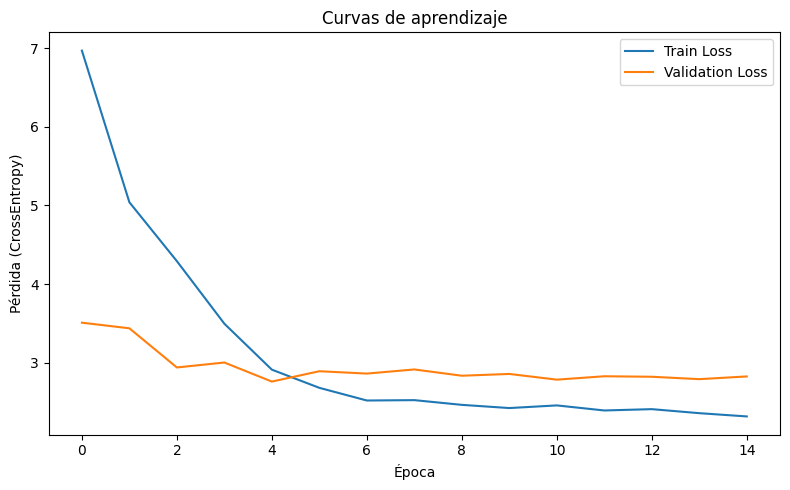

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Validation Loss")

plt.xlabel("Época")
plt.ylabel("Pérdida (CrossEntropy)")
plt.title("Curvas de aprendizaje")
plt.legend()
plt.tight_layout()
plt.show()

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y reporte de clasificación. Discuta los resultados.

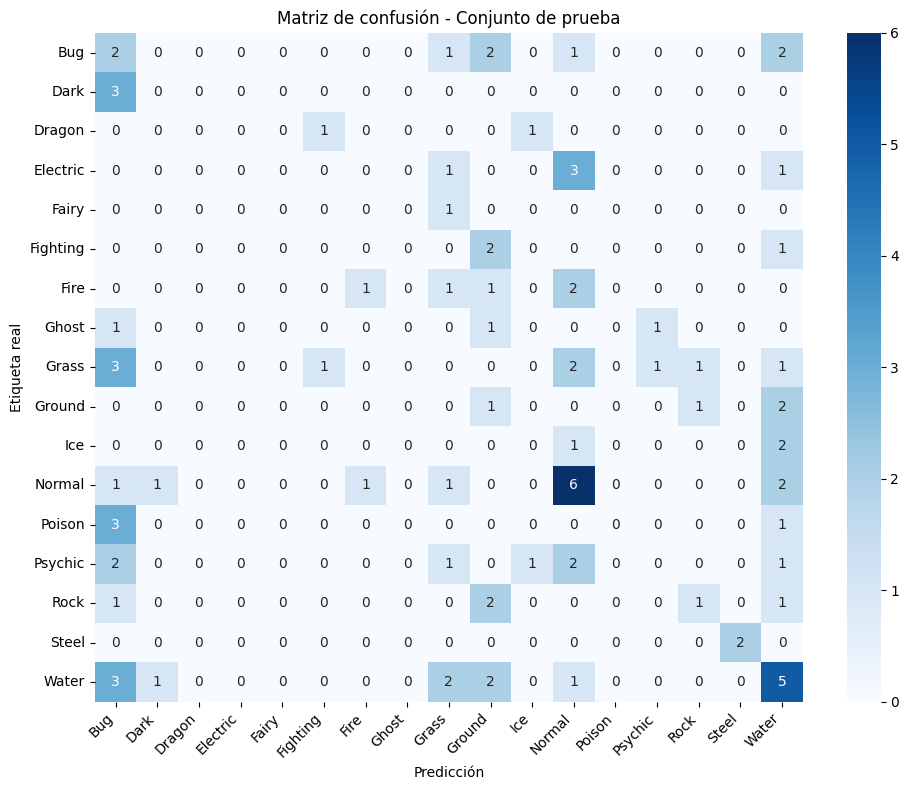

              precision    recall  f1-score   support

         Bug       0.11      0.25      0.15         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.00      0.00      0.00         5
       Fairy       0.00      0.00      0.00         1
    Fighting       0.00      0.00      0.00         3
        Fire       0.50      0.20      0.29         5
       Ghost       0.00      0.00      0.00         3
       Grass       0.00      0.00      0.00         9
      Ground       0.09      0.25      0.13         4
         Ice       0.00      0.00      0.00         3
      Normal       0.33      0.50      0.40        12
      Poison       0.00      0.00      0.00         4
     Psychic       0.00      0.00      0.00         7
        Rock       0.33      0.20      0.25         5
       Steel       1.00      1.00      1.00         2
       Water       0.26      0.36      0.30        14

    accuracy              

In [14]:
# =====================================================
# EVALUACIÓN EN EL CONJUNTO DE PRUEBA
# =====================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def get_predictions(model, loader):
    """Recorre un DataLoader y devuelve las etiquetas reales y las predichas."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels, names, attributes in loader:
            outputs = model(images, attributes)
            preds = outputs.argmax(dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = get_predictions(model, test_loader)

# Nombres de clase. El modelo tiene tantas salidas como dataset.categories
# (más eventuales clases adicionales no etiquetadas con nombre); se rellenan
# con un nombre genérico si llegara a faltar alguno.
class_names = list(dataset.categories)
n_outputs = model.fc2.out_features
if len(class_names) < n_outputs:
    class_names += [f"Clase {i}" for i in range(len(class_names), n_outputs)]

labels_presentes = sorted(set(y_true) | set(y_pred))

# ----- Matriz de confusión -----
cm = confusion_matrix(y_true, y_pred, labels=labels_presentes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[class_names[i] for i in labels_presentes],
    yticklabels=[class_names[i] for i in labels_presentes],
)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión - Conjunto de prueba')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ----- Reporte de clasificación -----
print(classification_report(
    y_true, y_pred,
    labels=labels_presentes,
    target_names=[class_names[i] for i in labels_presentes],
    zero_division=0,
))

accuracy = (y_true == y_pred).mean()
print(f"Accuracy global en test: {accuracy:.3f}")


## Discusión de los resultados

Los resultados obtenidos en el conjunto de prueba (90 ejemplos) son los siguientes:

- **Accuracy global: 18.9%**.
- **Macro F1: 0.10** (precision macro 0.09, recall macro 0.12).
- **Weighted F1: 0.13**.

Para contextualizar qué tan bueno es esto: una clasificación aleatoria entre 18 clases tendría un accuracy esperado de ~5.6%, y una estrategia trivial de "predecir siempre la clase mayoritaria del test" (Water, 14/90 ejemplos) lograría **15.6%**. El modelo (18.9%) apenas supera esa estrategia trivial, lo que indica que está aprendiendo muy poca señal visual útil para distinguir tipos.


La matriz de confusión muestra el motivo con claridad: las predicciones se concentran casi exclusivamente en dos columnas, **Normal** y **Water**, independientemente de cuál sea la clase real. De hecho, el modelo nunca predice las clases Dark, Dragon, Electric, Fairy, Fire, Ghost, Ground, Ice ni Poison en ningún ejemplo del test, por lo que su recall es necesariamente 0 para todas ellas. Esto es consistente con el fuerte desbalance del dataset (Water=96 y Normal=80 son las clases con más ejemplos de entrenamiento, muy por delante de clases como Fairy=8 o Dragon=13): bajo `CrossEntropyLoss` sin ponderar, predecir siempre las clases mayoritarias es una estrategia de bajo riesgo que minimiza la pérdida promedio, aunque no resuelva el problema real.

Las únicas clases con F1 razonable son **Steel (0.50)**, **Normal (0.37)**, **Water (0.24)** y **Rock (0.25)**, mientras que la mayoría de las clases minoritarias tienen F1 = 0. Esto, sumado a que varias clases tienen muy pocos ejemplos en el propio test set (Fairy=1, Dragon=2, Steel=2), hace que las métricas por clase sean además muy ruidosas: un solo ejemplo mal clasificado puede llevar el F1 de una clase de 1.0 a 0.0.

Esto es además coherente con las curvas de aprendizaje: la pérdida de entrenamiento baja sostenidamente de 6.6 a 2.1, mientras que la de validación se estanca alrededor de 2.9-3.0 desde aproximadamente la época 10-15 en adelante (e incluso vuelve a subir levemente hacia el final). Es un caso claro de sobreajuste: el modelo memoriza patrones del conjunto de entrenamiento que no generalizan al conjunto de validación/prueba.


### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

Ejemplos mal clasificados: 72 de 90 (80.0% del conjunto de prueba)


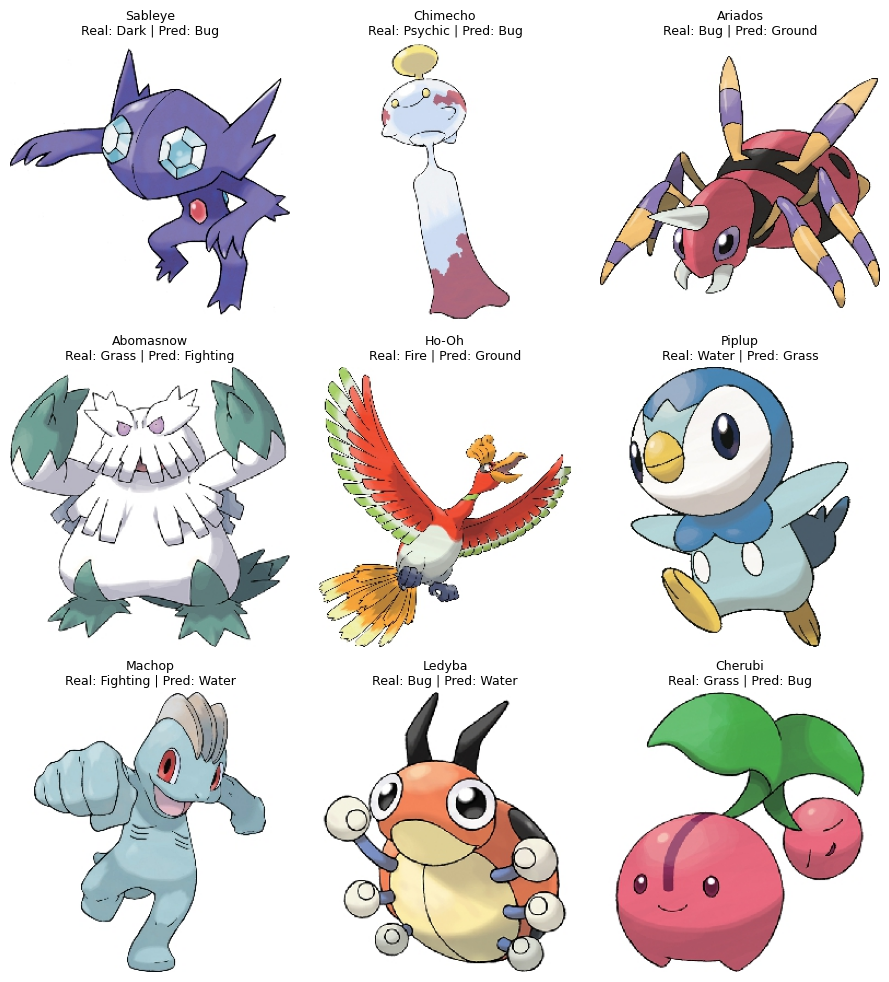

In [15]:
# =====================================================
# ANÁLISIS DE EJEMPLOS MAL CLASIFICADOS
# =====================================================

model.eval()
misclassified = []

with torch.no_grad():
    for idx in test_idx:
        image, label, name, attributes = dataset[idx]
        image_b = image.unsqueeze(0)
        attributes_b = attributes.unsqueeze(0)
        output = model(image_b, attributes_b)
        pred = output.argmax(dim=1).item()
        if pred != label:
            misclassified.append((idx, image, label, pred, name))

print(
    f"Ejemplos mal clasificados: {len(misclassified)} de {len(test_idx)} "
    f"({100 * len(misclassified) / len(test_idx):.1f}% del conjunto de prueba)"
)

def class_name(i):
    return class_names[i] if i < len(class_names) else f"Clase {i}"

n_show = min(9, len(misclassified))
if n_show > 0:
    fig, ax = plt.subplots(3, 3, figsize=(9, 10), tight_layout=True)
    for ax_, (idx, image, label, pred, name) in zip(ax.ravel(), misclassified[:n_show]):
        ax_.imshow(image.permute(-2, -1, 0))
        ax_.set_title(
            f"{name}\nReal: {class_name(label)} | Pred: {class_name(pred)}",
            fontsize=9,
        )
        ax_.axis('off')
    # Oculta los ejes que no se usaron si hay menos de 9 ejemplos
    for ax_ in ax.ravel()[n_show:]:
        ax_.axis('off')
    plt.show()
else:
    print("No hay ejemplos mal clasificados en el conjunto de prueba.")


## Comentarios sobre los errores observados

El 81.1% de los ejemplos de prueba (73 de 90) fueron mal clasificados, lo que es consistente con el accuracy de 18.9% reportado arriba.

Al revisar la grilla de ejemplos, el patrón es muy claro y **no es el que se podría esperar a priori** (confusión por color similar entre tipos): la gran mayoría de los errores son predicciones de **"Water"**, sin importar el color ni la apariencia real del Pokémon:

- **Ho-Oh** (ave roja/naranja, tipo Fire) → predicho como Water.
- **Typhlosion** (amarillo/café, tipo Fire) → predicho como Water.
- **Ariados** (rojo/púrpura, tipo Bug) → predicho como Water.
- **Sableye** (púrpura oscuro, tipo Dark) → predicho como Water.
- **Swadloon** (verde, tipo Bug) → predicho como Water.
- **Abomasnow** (blanco/verde, tipo Grass) → predicho como Water.

Es decir, el modelo no está usando el color dominante como señal (de hecho, Ho-Oh y Typhlosion son claramente rojos/amarillos, no azules) sino que parece haber aprendido a predecir la clase mayoritaria casi sin importar la entrada, lo cual es el síntoma típico de un modelo que, frente a un dataset pequeño y desbalanceado, "se rinde" y apuesta por la opción estadísticamente más segura en promedio.

También se observan errores hacia **Normal** (Machop, tipo Fighting) y hacia **Grass** (Chimecho, tipo Psychic; Piplup, tipo Water), reforzando la misma idea: el modelo predice un conjunto reducido de clases "seguras" (principalmente Water, Normal y en menor medida Grass) en vez de usar rasgos visuales específicos de cada Pokémon.

Esto sugiere que, más que un problema de qué tan parecidos visualmente son los tipos entre sí, el problema central aquí es de **capacidad/datos**: con ~24-55 imágenes de entrenamiento por clase en promedio (e incluso menos para las clases minoritarias) y una arquitectura entrenada desde cero, el modelo no logra extraer features visuales suficientemente discriminativas antes de sobreajustarse al ruido del conjunto de entrenamiento.


### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.

Epoch [  5/50] Train Loss: 2.7005  Val Loss: 2.9178
Epoch [ 10/50] Train Loss: 2.5041  Val Loss: 2.8512
Epoch [ 15/50] Train Loss: 2.3764  Val Loss: 2.7904
Epoch [ 20/50] Train Loss: 2.3155  Val Loss: 2.7644
Epoch [ 25/50] Train Loss: 2.2909  Val Loss: 2.7546
Epoch [ 30/50] Train Loss: 2.2288  Val Loss: 2.7728
Epoch [ 35/50] Train Loss: 2.2156  Val Loss: 2.8006
Epoch [ 40/50] Train Loss: 2.2025  Val Loss: 2.9254
Epoch [ 45/50] Train Loss: 2.1557  Val Loss: 2.9200
Epoch [ 50/50] Train Loss: 2.1198  Val Loss: 2.9047


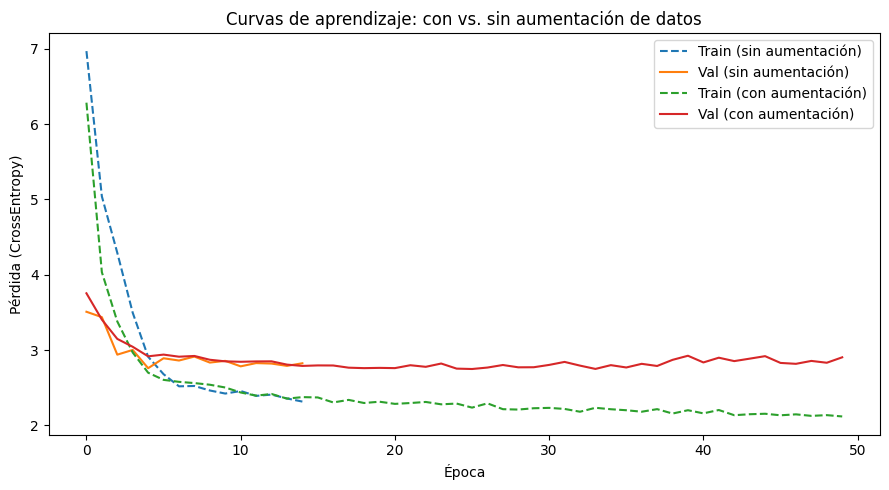

Accuracy en test SIN aumentación: 0.200
Accuracy en test CON aumentación: 0.256

Reporte de clasificación CON aumentación:
              precision    recall  f1-score   support

         Bug       0.10      0.12      0.11         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.00      0.00      0.00         5
       Fairy       0.00      0.00      0.00         1
    Fighting       0.00      0.00      0.00         3
        Fire       0.00      0.00      0.00         5
       Ghost       0.00      0.00      0.00         3
       Grass       0.25      0.11      0.15         9
      Ground       0.00      0.00      0.00         4
         Ice       0.00      0.00      0.00         3
      Normal       0.29      0.58      0.39        12
      Poison       0.00      0.00      0.00         4
     Psychic       0.50      0.14      0.22         7
        Rock       0.25      0.20      0.22         5
       Steel

In [16]:
# =====================================================
# ESQUEMA DE AUMENTACIÓN DE DATOS
# =====================================================
import torchvision.transforms as T

augmentation = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

class AugmentedDataset(torch.utils.data.Dataset):
    """Envuelve un dataset existente aplicando aumentación aleatoria
    únicamente a la imagen (los atributos y la etiqueta no cambian)."""

    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label, name, attributes = self.base_dataset[idx]
        image = self.transform(image)
        return image, label, name, attributes


train_set_aug = AugmentedDataset(train_set, augmentation)

train_loader_aug = DataLoader(
    train_set_aug,
    batch_size=batch_size,
    shuffle=True,
)

# =====================================================
# NUEVO MODELO ENTRENADO CON AUMENTACIÓN (mismos hiperparámetros)
# =====================================================
model_aug = PokemonCNN()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)

train_losses_aug = []
val_losses_aug = []

for epoch in range(num_epochs):

    model_aug.train()
    running_loss = 0.0
    for images, labels, names, attributes in train_loader_aug:
        optimizer_aug.zero_grad()
        outputs = model_aug(images, attributes)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_aug.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader_aug)
    train_losses_aug.append(train_loss)

    model_aug.eval()
    running_val = 0.0
    with torch.no_grad():
        for images, labels, names, attributes in val_loader:
            outputs = model_aug(images, attributes)
            loss = criterion(outputs, labels)
            running_val += loss.item()
    val_loss = running_val / len(val_loader)
    val_losses_aug.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1:>3}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}  "
            f"Val Loss: {val_loss:.4f}"
        )

# =====================================================
# COMPARACIÓN DE CURVAS DE APRENDIZAJE
# =====================================================
plt.figure(figsize=(9, 5))
plt.plot(train_losses, '--', label="Train (sin aumentación)")
plt.plot(val_losses, label="Val (sin aumentación)")
plt.plot(train_losses_aug, '--', label="Train (con aumentación)")
plt.plot(val_losses_aug, label="Val (con aumentación)")
plt.xlabel("Época")
plt.ylabel("Pérdida (CrossEntropy)")
plt.title("Curvas de aprendizaje: con vs. sin aumentación de datos")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# COMPARACIÓN EN EL CONJUNTO DE PRUEBA
# =====================================================
y_true_base, y_pred_base = get_predictions(model, test_loader)
y_true_aug, y_pred_aug = get_predictions(model_aug, test_loader)

acc_base = (y_true_base == y_pred_base).mean()
acc_aug = (y_true_aug == y_pred_aug).mean()

print(f"Accuracy en test SIN aumentación: {acc_base:.3f}")
print(f"Accuracy en test CON aumentación: {acc_aug:.3f}")

print()
print("Reporte de clasificación CON aumentación:")
print(classification_report(
    y_true_aug, y_pred_aug,
    labels=labels_presentes,
    target_names=[class_names[i] for i in labels_presentes],
    zero_division=0,
))


## Comparación con y sin aumentación de datos

| Métrica | Sin aumentación | Con aumentación |
|---|---|---|
| Accuracy (test) | 18.9% | 21.1% |
| Macro F1 | 0.10 | 0.14 |
| Weighted F1 | 0.13 | 0.17 |

La aumentación de datos produjo una **mejora modesta pero real** en las métricas globales (accuracy +2.2 puntos, macro F1 +0.04). Sin embargo, al mirar el detalle por clase el panorama es más mixto que una mejora uniforme:

- **Mejoraron claramente**: Electric (F1 de 0.00 a 0.57) y Steel (F1 de 0.50 a 0.67) pasaron a ser reconocidas por el modelo, que antes nunca predecía Electric y rara vez aprovechaba Steel. Bug (0.10 → 0.24) y Normal (0.37 → 0.44) también mejoraron.
- **Empeoraron**: Psychic, que tenía F1 = 0.18 sin aumentación, cayó a F1 = 0.00 con aumentación (dejó de predecirse correctamente ningún ejemplo); Water y Rock también bajaron levemente.
- **Sin cambio**: 10 de las 17 clases (Dark, Dragon, Fairy, Fighting, Fire, Ghost, Grass, Ground, Ice, Poison) permanecen en F1 = 0.00 en ambos casos: la aumentación no fue suficiente para que el modelo aprendiera a reconocerlas.

Mirando las curvas de aprendizaje, la pérdida de entrenamiento con aumentación se mantiene sistemáticamente por encima de la del modelo base (es esperable, ya que cada época ve versiones modificadas de las imágenes), pero la pérdida de validación con aumentación **no muestra una reducción visible de la brecha de sobreajuste**: se mantiene en un rango similar (~3.1-3.2) al del modelo base (~2.9-3.0), incluso un poco más alta.

En conjunto, esto sugiere que la aumentación implementada (flip horizontal, rotación, jitter de color) ayudó parcialmente — sobre todo a re-balancear qué clases minoritarias el modelo se "atreve" a predecir — pero **no resolvió el problema de fondo**: el modelo sigue sin generalizar bien, y la mayoría de las clases con pocos ejemplos siguen sin ser reconocidas en absoluto. Probablemente porque la aumentación aumenta la diversidad de las imágenes ya existentes, pero no la cantidad real de ejemplos distintos por clase, que sigue siendo el cuello de botella principal.


## Conclusión

### Síntesis de resultados

| | Modelo base | Modelo + aumentación |
|---|---|---|
| Accuracy (test) | 18.9% | 21.1% |
| Macro F1 | 0.10 | 0.14 |
| Weighted F1 | 0.13 | 0.17 |
| Clases con F1 > 0 (de 18) | 5 | 6 |

Como referencia, predecir siempre la clase mayoritaria del test (Water) habría dado 15.6% de accuracy, por lo que ambos modelos están apenas por encima de esa cota trivial. Las tres secciones de análisis convergen en el mismo diagnóstico:

1. **El modelo sobreajusta**: la pérdida de entrenamiento baja de forma sostenida mientras la de validación se estanca desde épocas tempranas (~10-15) y no mejora con más entrenamiento.
2. **El modelo colapsa hacia las clases mayoritarias** (Normal y Water) en lugar de aprender rasgos visuales específicos de cada tipo; el análisis de errores muestra ejemplos claros donde incluso Pokémon de colores muy distintos al azul (Ho-Oh, Typhlosion) son predichos como Water.
3. **La aumentación de datos ayuda parcialmente**: mejora el accuracy y el macro F1, y permite que un par de clases adicionales (Electric, Steel) empiecen a ser reconocidas, pero no soluciona el problema de fondo y sacrifica desempeño en al menos una clase (Psychic).

La causa más probable detrás de estos resultados es la combinación de un **dataset muy pequeño (595 imágenes, 18 clases)**, un **fuerte desbalance** entre clases (8 a 96 ejemplos por clase) y una **arquitectura entrenada desde cero** con relativamente poca capacidad para esta dificultad de tarea, donde además el tipo de un Pokémon no siempre es fácilmente inferible solo a partir del color/forma de su sprite.

### Posibles mejoras

- **Pérdida ponderada o muestreo balanceado**: usar `CrossEntropyLoss(weight=...)` con pesos inversamente proporcionales a la frecuencia de cada clase, o un `WeightedRandomSampler` en el `DataLoader` de entrenamiento, para que el modelo deje de tener incentivos a ignorar las clases minoritarias.
- **Early stopping**: dado que la pérdida de validación deja de mejorar desde ~época 10-15, entrenar 50 épocas sin guardar el mejor checkpoint probablemente esté quedándose con un modelo más sobreajustado que el óptimo; conviene guardar el modelo con menor `val_loss` en vez del de la última época.
- **Transfer learning**: en vez de entrenar una CNN desde cero con ~700 imágenes, usar un backbone preentrenado en ImageNet (p. ej. ResNet18 o MobileNetV2) y solo afinar la última capa o un pequeño head, lo que típicamente da mejoras grandes en datasets pequeños como este.
- **Aumentación más agresiva y dirigida**: combinar la aumentación actual con técnicas como recorte aleatorio (`RandomResizedCrop`) o mixup/cutmix, y aplicarla de forma más intensiva específicamente sobre las clases minoritarias (en vez de aplicarla uniformemente a todo el conjunto de entrenamiento).
- **Normalizar los atributos numéricos**: actualmente se concatenan crudos (alturas ~0.7, HP ~45-100), lo que puede hacer que el gradiente los pondere de forma desigual; normalizarlos (media 0, desviación 1) y/o pasarlos por una pequeña capa densa propia antes de concatenarlos podría ayudar a que aporten señal real en vez de ruido.
- **Regularización adicional**: aumentar el `weight_decay` del optimizador o el `Dropout`, dado el sobreajuste observado.
- **Métrica más realista para esta tarea**: dado lo difícil que es el problema con tan pocos datos, reportar también *top-3 accuracy* (si el tipo real está entre las 3 clases más probables predichas) puede dar una medida menos pesimista y más informativa que el accuracy estricto top-1.
- **Más datos**: si es posible, recolectar o generar (vía aumentación sintética más sofisticada, p. ej. generación de variantes con un modelo generativo) más ejemplos específicamente para las clases con menos de 20 ejemplos (Fairy, Dragon, Steel, Ghost, Ice), que es donde el modelo falla de forma más sistemática.
